<a href="https://colab.research.google.com/github/salsilsulselsol/Data-Scientist-Supervisor-Nasional-Experiment/blob/main/01_Data_Screening.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 1: Data Screening and Validation

**Objective:**
Perform initial data screening, structural description, and quality verification to ensure data readiness for the modeling pipeline.

**Dataset Context:**
Bank Customer Churn Prediction. The dataset contains customer demographics, account information, and status (whether they left the bank).
*Source: Public GitHub Repository [selva86/datasets](https://raw.githubusercontent.com/selva86/datasets/master/Churn_Modelling.csv).*

In [2]:
# Import necessary data manipulation and visualization libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configure visual aesthetics for plots
sns.set_theme(style="whitegrid")

# Define a stable data source URL (Bank Customer Churn)
data_url = "https://raw.githubusercontent.com/selva86/datasets/master/Churn_Modelling.csv"

# Load the dataset directly into a pandas DataFrame with error handling
try:
    df = pd.read_csv(data_url)
    print(f"Data loading complete. Total Rows: {df.shape[0]}, Total Columns: {df.shape[1]}")
except Exception as e:
    print(f"Error loading data: {e}")

Data loading complete. Total Rows: 10000, Total Columns: 14


## Step 1: Data Schema Validation and Descriptive Statistics

**Goal:**
Understand the structural properties of the dataset, including memory usage, data types, and the distribution of numerical features.

In [4]:
print("--- DATA SCHEMA & TYPES ---")
df.info()

--- DATA SCHEMA & TYPES ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [5]:
print("\n--- DESCRIPTIVE STATISTICS ---")
print(df.describe())


--- DESCRIPTIVE STATISTICS ---
         RowNumber    CustomerId   CreditScore           Age        Tenure  \
count  10000.00000  1.000000e+04  10000.000000  10000.000000  10000.000000   
mean    5000.50000  1.569094e+07    650.528800     38.921800      5.012800   
std     2886.89568  7.193619e+04     96.653299     10.487806      2.892174   
min        1.00000  1.556570e+07    350.000000     18.000000      0.000000   
25%     2500.75000  1.562853e+07    584.000000     32.000000      3.000000   
50%     5000.50000  1.569074e+07    652.000000     37.000000      5.000000   
75%     7500.25000  1.575323e+07    718.000000     44.000000      7.000000   
max    10000.00000  1.581569e+07    850.000000     92.000000     10.000000   

             Balance  NumOfProducts    HasCrCard  IsActiveMember  \
count   10000.000000   10000.000000  10000.00000    10000.000000   
mean    76485.889288       1.530200      0.70550        0.515100   
std     62397.405202       0.581654      0.45584        0.499

In [6]:
print("\n--- FIRST 5 ROWS ---")
print(df.head())


--- FIRST 5 ROWS ---
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63  

In [7]:
print("\n--- UNIQUE VALUES PER FEATURE ---")
# Count unique values to identify potential categorical variables
for column in df.columns:
    print(f"{column}: {df[column].nunique()} unique values")


--- UNIQUE VALUES PER FEATURE ---
RowNumber: 10000 unique values
CustomerId: 10000 unique values
Surname: 2932 unique values
CreditScore: 460 unique values
Geography: 3 unique values
Gender: 2 unique values
Age: 70 unique values
Tenure: 11 unique values
Balance: 6382 unique values
NumOfProducts: 4 unique values
HasCrCard: 2 unique values
IsActiveMember: 2 unique values
EstimatedSalary: 9999 unique values
Exited: 2 unique values


## Step 2: Quality Verification and Anomaly Detection

**Goal:**
Identify common data quality issues such as missing values, duplicate records, logical range violations, and extreme outliers.

In [8]:
# 1. Missing Values Detection
print("--- 1. MISSING VALUES REPORT ---")
missing_report = df.isnull().sum()
if missing_report.any():
    missing_percentage = (missing_report / len(df)) * 100
    missing_df = pd.DataFrame({'Missing Count': missing_report, 'Percentage (%)': missing_percentage})
    print(missing_df[missing_df['Missing Count'] > 0])
else:
    print("Result: No missing values detected in the dataset.")

--- 1. MISSING VALUES REPORT ---
Result: No missing values detected in the dataset.


In [10]:
# 2. Duplicate Record Detection
print("--- 2. DUPLICATE RECORD REPORT ---")
duplicate_count = df.duplicated().sum()
print(f"Result: Found {duplicate_count} exact duplicate rows.")

--- 2. DUPLICATE RECORD REPORT ---
Result: Found 0 exact duplicate rows.


In [11]:
# 3. Logical Consistency & Range Validation
print("--- 3. LOGICAL CONSISTENCY CHECKS ---")
# Validate Age constraint (must be positive and within human lifespan limits)
invalid_age = df[(df['Age'] <= 0) | (df['Age'] > 120)]
print(f"Result: Found {len(invalid_age)} records with unrealistic age values.")

# Validate Credit Score constraint (Standard FICO scores range from 300 to 850)
invalid_credit = df[(df['CreditScore'] < 300) | (df['CreditScore'] > 850)]
print(f"Result: Found {len(invalid_credit)} records with out-of-range credit scores.")

--- 3. LOGICAL CONSISTENCY CHECKS ---
Result: Found 0 records with unrealistic age values.
Result: Found 0 records with out-of-range credit scores.



--- 4. DATA DISTRIBUTION & OUTLIER VISUALIZATION ---


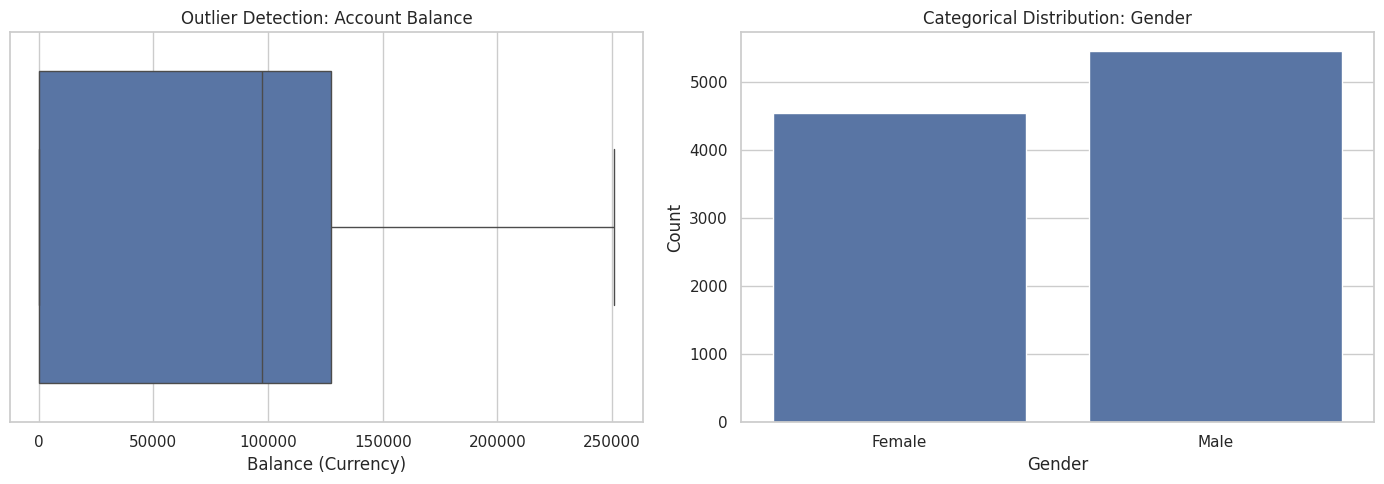

In [12]:
# 4. Outlier and Distribution Detection (Visualization)
print("\n--- 4. DATA DISTRIBUTION & OUTLIER VISUALIZATION ---")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot for Outlier Detection
sns.boxplot(ax=axes[0], x=df['Balance'])
axes[0].set_title('Outlier Detection: Account Balance')
axes[0].set_xlabel('Balance (Currency)')

# Countplot for Categorical Distribution
sns.countplot(ax=axes[1], x='Gender', data=df)
axes[1].set_title('Categorical Distribution: Gender')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()